# Walmart Weekly Sales — Capstone Project
**Data Science with Python | Google Colab**

### Covers:
- Data Loading & Inspection
- Missing Value Analysis
- Outlier Detection & Treatment
- EDA & Statistical Analysis
- Business Insights (Questions a–f)
- Predictive Modelling — 12-Week Forecast per Store


## Section 0 — Install & Import Libraries

In [1]:
# Install extra libraries (statsmodels for time-series)
!pip install -q statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
print('All libraries loaded successfully')


All libraries loaded successfully


## Section 1 — Data Loading & Inspection

In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('Walmart DataSet (2).csv')

# Parse date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Feature engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['Month_Name'] = df['Date'].dt.strftime('%b')

print(f'Shape: {df.shape}')
print(f'Date range: {df.Date.min().date()} to {df.Date.max().date()}')
print(f'Stores: {df.Store.nunique()} unique')

df.head()


Saving Walmart DataSet.csv to Walmart DataSet (3).csv
Shape: (6435, 13)
Date range: 2010-02-05 to 2012-10-26
Stores: 45 unique


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Month_Name
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1,Feb
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1,Feb
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1,Feb
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1,Feb
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1,Mar


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   int64         
 11  Quarter       6435 non-null   int32         
 12  Month_Name    6435 non-null   object        
dtypes: datetime64[ns](1), float64(5), int32(3), int64(3), object(1)
memory usage: 578.3+ KB


In [11]:
df.describe().round(2)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
count,6435.00,6435,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,2011-06-17 00:00:00,1046964.88,0.07,60.66,3.36,171.58,8.00,2010.97,6.45,25.82,2.48
min,1.00,2010-02-05 00:00:00,209986.25,0.00,-2.06,2.47,126.06,3.88,2010.00,1.00,1.00,1.00
25%,12.00,2010-10-08 00:00:00,553350.10,0.00,47.46,2.93,131.74,6.89,2010.00,4.00,14.00,2.00
50%,23.00,2011-06-17 00:00:00,960746.04,0.00,62.67,3.44,182.62,7.87,2011.00,6.00,26.00,2.00
75%,34.00,2012-02-24 00:00:00,1420158.66,0.00,74.94,3.74,212.74,8.62,2012.00,9.00,38.00,3.00
max,45.00,2012-10-26 00:00:00,3818686.45,1.00,100.14,4.47,227.23,14.31,2012.00,12.00,52.00,4.00
std,12.99,NaN,564366.62,0.26,18.44,0.46,39.36,1.88,0.80,3.24,14.13,1.07


## Section 2 — Missing Value Analysis

          Column  Missing_Count  Missing_Pct
0          Store              0          0.0
1           Date              0          0.0
2   Weekly_Sales              0          0.0
3   Holiday_Flag              0          0.0
4    Temperature              0          0.0
5     Fuel_Price              0          0.0
6            CPI              0          0.0
7   Unemployment              0          0.0
8           Year              0          0.0
9          Month              0          0.0
10          Week              0          0.0
11       Quarter              0          0.0
12    Month_Name              0          0.0


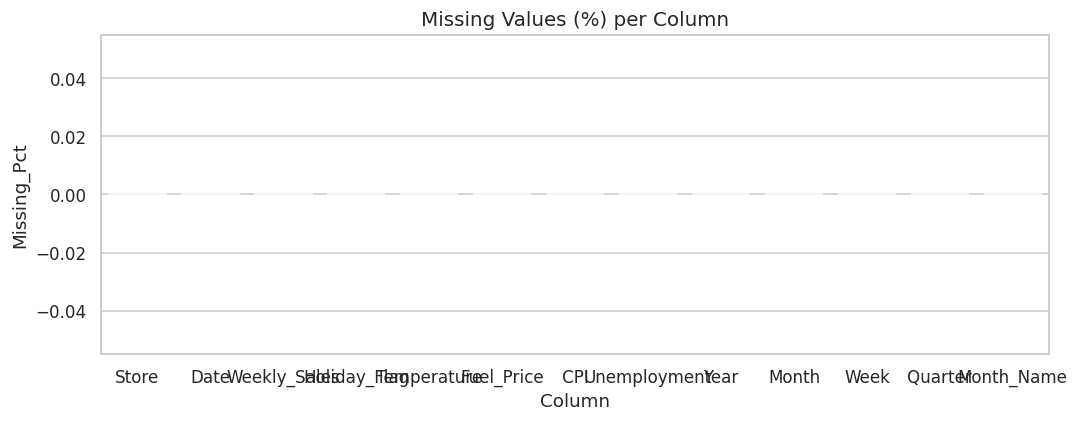

Missing values after imputation: 0


In [12]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Column', 'Missing_Count']
missing['Missing_Pct'] = (missing['Missing_Count'] / len(df) * 100).round(2)
print(missing)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=missing, x='Column', y='Missing_Pct', palette='Blues_d', ax=ax)
ax.set_title('Missing Values (%) per Column', fontsize=13)
plt.tight_layout(); plt.show()

# Impute with median
num_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
print(f'Missing values after imputation: {df.isnull().sum().sum()}')


## Section 3 — Outlier Detection & Treatment

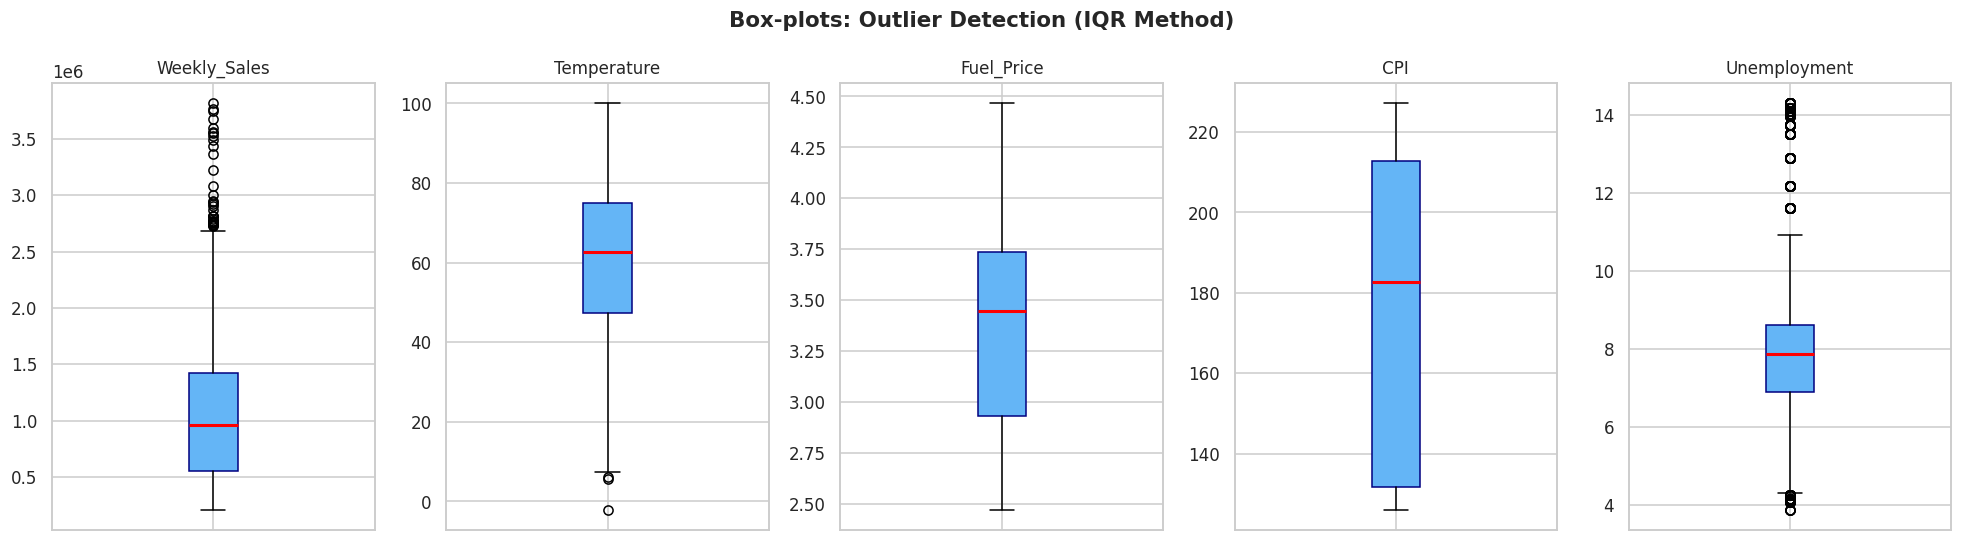

In [13]:
# 3.1  Box-plots
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#64B5F6', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticklabels([])
fig.suptitle('Box-plots: Outlier Detection (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [14]:
# 3.2  IQR Summary
print(f"{'Column':<18} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12} {'#Outliers':>10}")
print('-'*84)
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5*IQR
    hi  = Q3 + 1.5*IQR
    n   = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col:<18} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lo:>12.2f} {hi:>12.2f} {n:>10}')

# 3.3  Winsorise Weekly_Sales
lo_ws = df['Weekly_Sales'].quantile(0.05)
hi_ws = df['Weekly_Sales'].quantile(0.95)
df['Weekly_Sales_Clean'] = df['Weekly_Sales'].clip(lower=lo_ws, upper=hi_ws)
print(f'\nWeekly_Sales winsorised to [{lo_ws:,.0f}  -  {hi_ws:,.0f}]')


Column                     Q1         Q3        IQR        Lower        Upper  #Outliers
------------------------------------------------------------------------------------
Weekly_Sales        553350.10 1420158.66  866808.55   -746862.73   2720371.49         34
Temperature             47.46      74.94      27.48         6.24       116.16          3
Fuel_Price               2.93       3.73       0.80         1.73         4.94          0
CPI                    131.74     212.74      81.01        10.22       334.26          0
Unemployment             6.89       8.62       1.73         4.29        11.22        481

Weekly_Sales winsorised to [308,427  -  2,049,179]


## Section 4 — Exploratory Data Analysis (EDA)

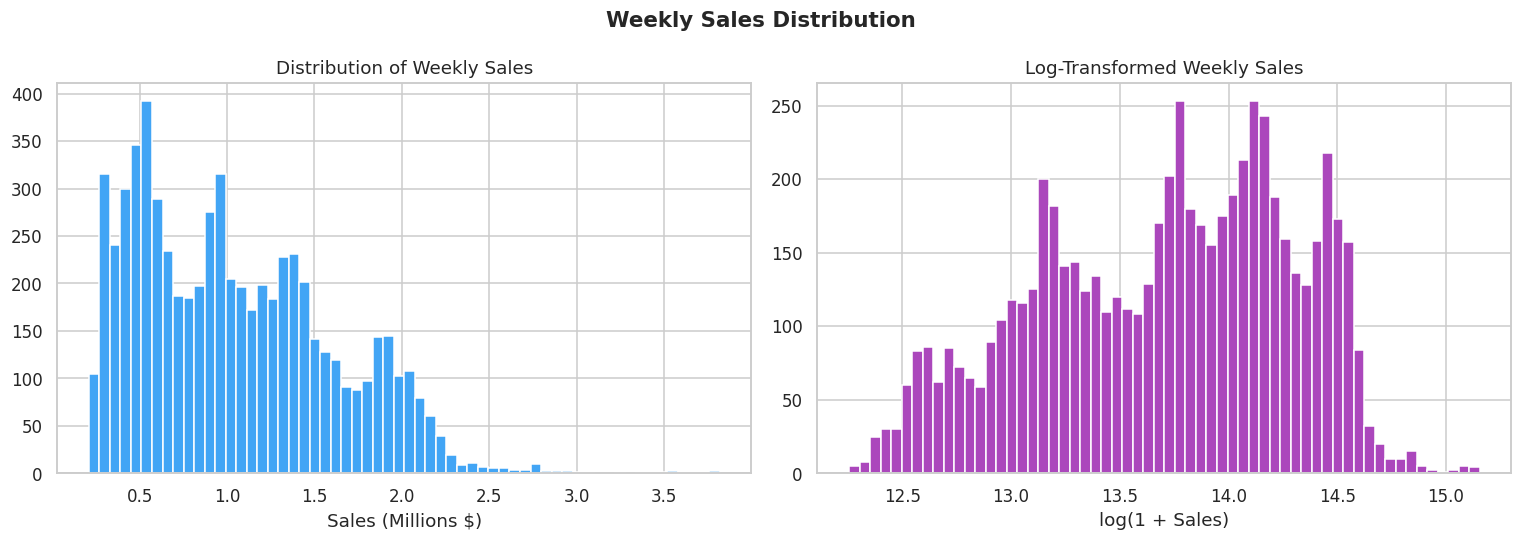

Skewness : 0.668
Kurtosis : 0.053


In [15]:
# 4.1  Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Weekly_Sales']/1e6, bins=60, color='#42A5F5', edgecolor='white')
axes[0].set_title('Distribution of Weekly Sales')
axes[0].set_xlabel('Sales (Millions $)')
axes[1].hist(np.log1p(df['Weekly_Sales']), bins=60, color='#AB47BC', edgecolor='white')
axes[1].set_title('Log-Transformed Weekly Sales')
axes[1].set_xlabel('log(1 + Sales)')
plt.suptitle('Weekly Sales Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Skewness : {df.Weekly_Sales.skew():.3f}')
print(f'Kurtosis : {df.Weekly_Sales.kurt():.3f}')


                   mean      median        std  count
Non-Holiday  1041256.38   956211.20  558957.44   5985
Holiday      1122887.89  1018538.04  627684.93    450


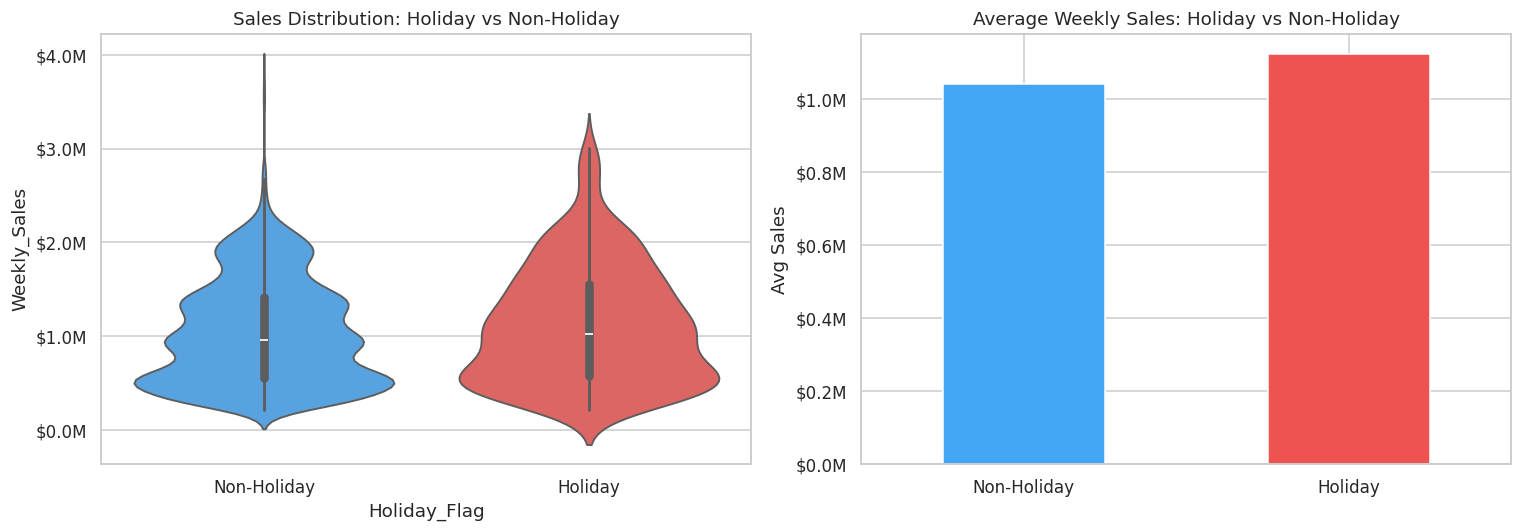

In [16]:
# 4.2  Holiday vs Non-Holiday
hol_summary = df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean','median','std','count'])
hol_summary.index = ['Non-Holiday','Holiday']
print(hol_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='Holiday_Flag', y='Weekly_Sales',
               palette=['#42A5F5','#EF5350'], ax=axes[0])
axes[0].set_xticklabels(['Non-Holiday','Holiday'])
axes[0].set_title('Sales Distribution: Holiday vs Non-Holiday')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
hol_summary['mean'].plot(kind='bar', ax=axes[1], color=['#42A5F5','#EF5350'], rot=0)
axes[1].set_title('Average Weekly Sales: Holiday vs Non-Holiday')
axes[1].set_xticklabels(['Non-Holiday','Holiday'], rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].set_ylabel('Avg Sales')
plt.tight_layout(); plt.show()


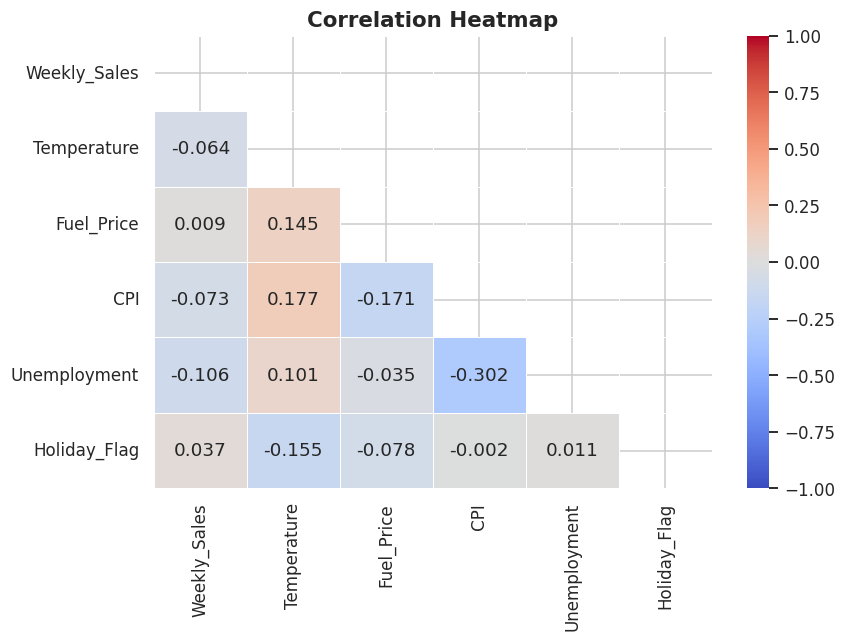

In [17]:
# 4.3  Correlation Heatmap
corr_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Section 5 — Business Insights
### 5a — Does Unemployment Affect Weekly Sales?

Pearson r = -0.1062   p-value = 0.000000
SIGNIFICANT relationship

Top 5 stores with highest avg unemployment:
 Store    Avg_Sales  Avg_Unemployment
    12 1.009002e+06         13.116483
    38 3.857317e+05         13.116483
    28 1.323522e+06         13.116483
    43 6.333247e+05          9.934804
    34 9.667816e+05          9.934804


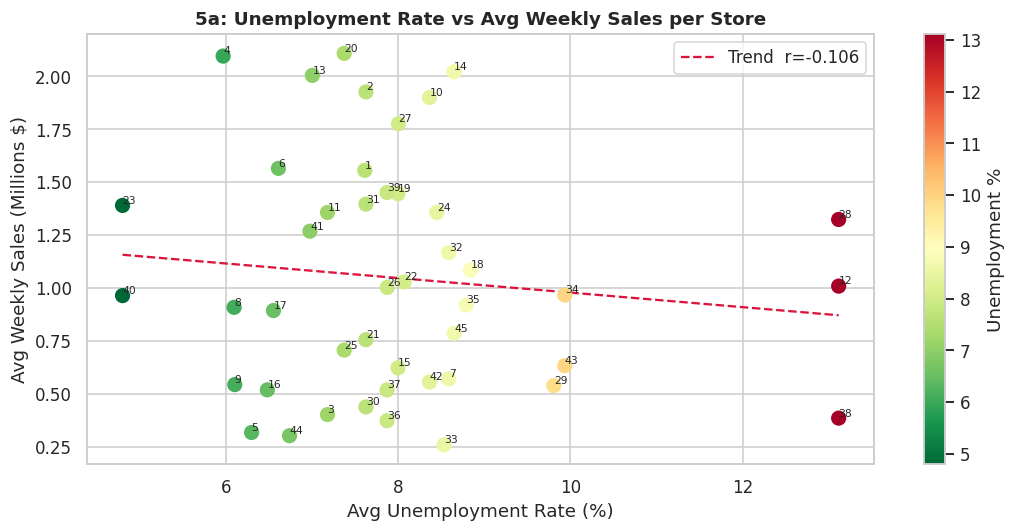

In [18]:
r_u, p_u = stats.pearsonr(df['Weekly_Sales'], df['Unemployment'])
print(f'Pearson r = {r_u:.4f}   p-value = {p_u:.6f}')
print('SIGNIFICANT relationship' if p_u < 0.05 else 'NOT significant')

store_unemp = (df.groupby('Store')
               .agg(Avg_Sales=('Weekly_Sales','mean'),
                    Avg_Unemployment=('Unemployment','mean'))
               .reset_index()
               .sort_values('Avg_Unemployment', ascending=False))
print('\nTop 5 stores with highest avg unemployment:')
print(store_unemp.head(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(store_unemp['Avg_Unemployment'], store_unemp['Avg_Sales']/1e6,
                c=store_unemp['Avg_Unemployment'], cmap='RdYlGn_r', s=80, zorder=3)
for _, row in store_unemp.iterrows():
    ax.annotate(int(row.Store),(row.Avg_Unemployment, row.Avg_Sales/1e6),
                fontsize=7, ha='left', va='bottom')
m,b = np.polyfit(store_unemp['Avg_Unemployment'], store_unemp['Avg_Sales']/1e6, 1)
xl = np.linspace(store_unemp['Avg_Unemployment'].min(), store_unemp['Avg_Unemployment'].max(), 100)
ax.plot(xl, m*xl+b, '--', color='crimson', linewidth=1.5, label=f'Trend  r={r_u:.3f}')
plt.colorbar(sc, ax=ax, label='Unemployment %')
ax.set_xlabel('Avg Unemployment Rate (%)'); ax.set_ylabel('Avg Weekly Sales (Millions $)')
ax.set_title('5a: Unemployment Rate vs Avg Weekly Sales per Store', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### 5b — Seasonal Trend in Weekly Sales

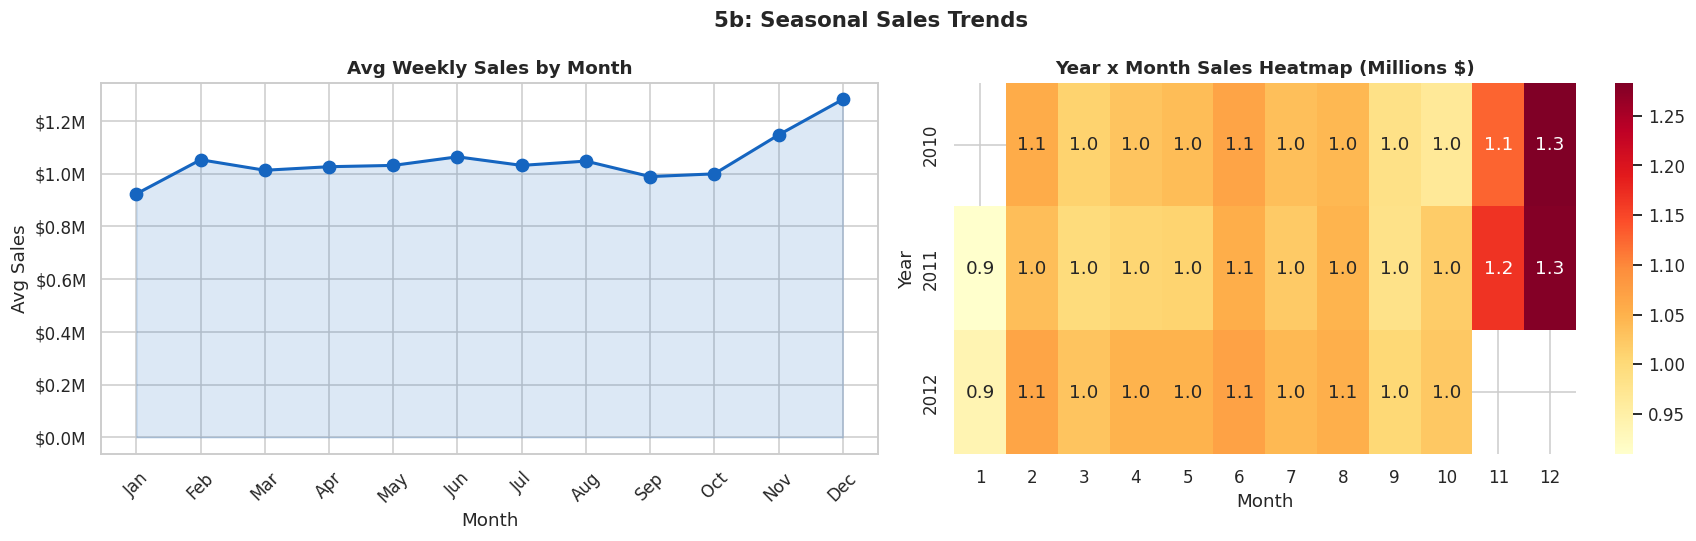

Peak month   : Dec
Lowest month : Jan
Nov-Dec spike driven by Thanksgiving & Christmas holiday shopping


In [19]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly     = df.groupby(['Year','Month','Month_Name'])['Weekly_Sales'].mean().reset_index()
monthly_avg = (df.groupby('Month_Name')['Weekly_Sales'].mean()
               .reindex(month_order).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(12), monthly_avg['Weekly_Sales']/1e6,
             marker='o', color='#1565C0', linewidth=2, markersize=8)
axes[0].fill_between(range(12), monthly_avg['Weekly_Sales']/1e6, alpha=0.15, color='#1565C0')
axes[0].set_xticks(range(12)); axes[0].set_xticklabels(month_order, rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
axes[0].set_title('Avg Weekly Sales by Month', fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Avg Sales')

pivot = monthly.pivot_table(index='Year', columns='Month', values='Weekly_Sales')
sns.heatmap(pivot/1e6, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Year x Month Sales Heatmap (Millions $)', fontweight='bold')
plt.suptitle('5b: Seasonal Sales Trends', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

peak   = monthly_avg.loc[monthly_avg.Weekly_Sales.idxmax(), 'Month_Name']
lowest = monthly_avg.loc[monthly_avg.Weekly_Sales.idxmin(), 'Month_Name']
print(f'Peak month   : {peak}')
print(f'Lowest month : {lowest}')
print('Nov-Dec spike driven by Thanksgiving & Christmas holiday shopping')


### 5c — Does Temperature Affect Weekly Sales?

Pearson r = -0.0638   p-value = 0.000000

Avg sales by Temperature Band:
Temp_Band  Weekly_Sales
     <20F  8.458347e+05
   20-40F  1.103830e+06
   40-60F  1.071085e+06
   60-80F  1.059193e+06
     >80F  9.420565e+05


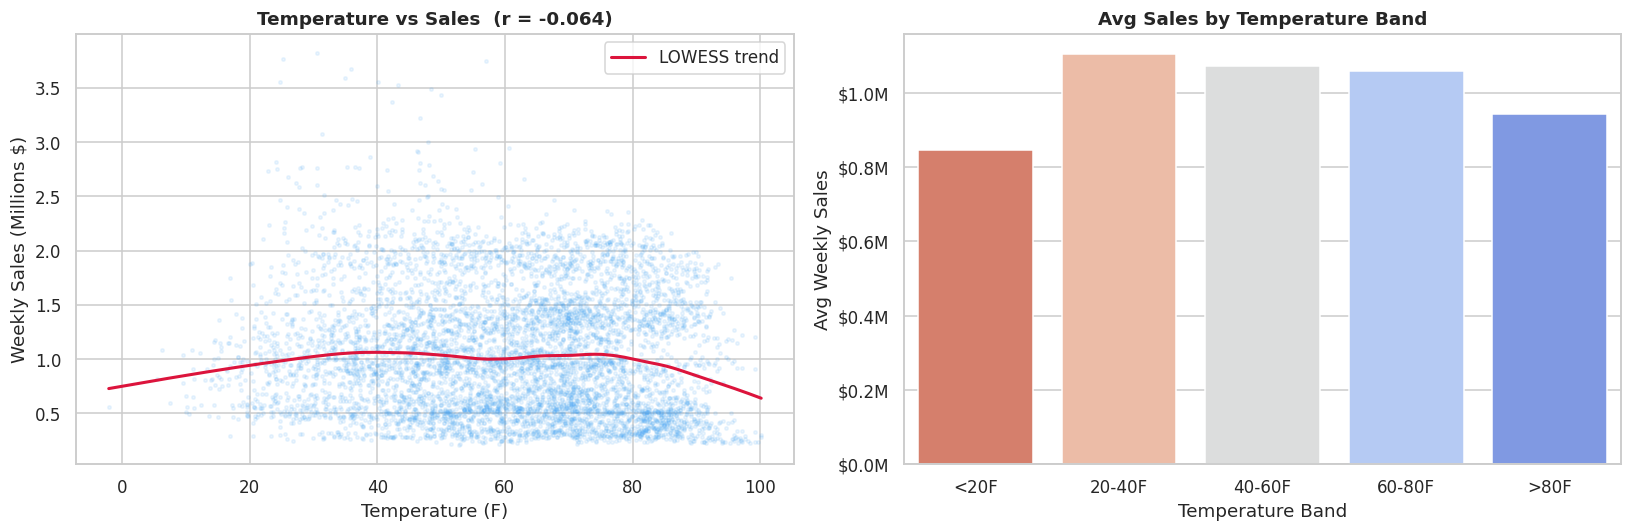

In [20]:
r_t, p_t = stats.pearsonr(df['Weekly_Sales'], df['Temperature'])
print(f'Pearson r = {r_t:.4f}   p-value = {p_t:.6f}')

bins   = [-np.inf, 20, 40, 60, 80, np.inf]
labels = ['<20F','20-40F','40-60F','60-80F','>80F']
df['Temp_Band'] = pd.cut(df['Temperature'], bins=bins, labels=labels)
band_sales = df.groupby('Temp_Band')['Weekly_Sales'].mean().reset_index()
print('\nAvg sales by Temperature Band:')
print(band_sales.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df['Temperature'], df['Weekly_Sales']/1e6, alpha=0.1, color='#42A5F5', s=5)
smth = lowess(df['Weekly_Sales']/1e6, df['Temperature'], frac=0.3)
axes[0].plot(smth[:,0], smth[:,1], color='crimson', linewidth=2, label='LOWESS trend')
axes[0].set_xlabel('Temperature (F)'); axes[0].set_ylabel('Weekly Sales (Millions $)')
axes[0].set_title(f'Temperature vs Sales  (r = {r_t:.3f})', fontweight='bold')
axes[0].legend()
sns.barplot(data=band_sales, x='Temp_Band', y='Weekly_Sales', palette='coolwarm_r', ax=axes[1])
axes[1].set_title('Avg Sales by Temperature Band', fontweight='bold')
axes[1].set_xlabel('Temperature Band'); axes[1].set_ylabel('Avg Weekly Sales')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
plt.tight_layout(); plt.show()


### 5d — How Does CPI Affect Weekly Sales?

Pearson r = -0.0726   p-value = 0.000000


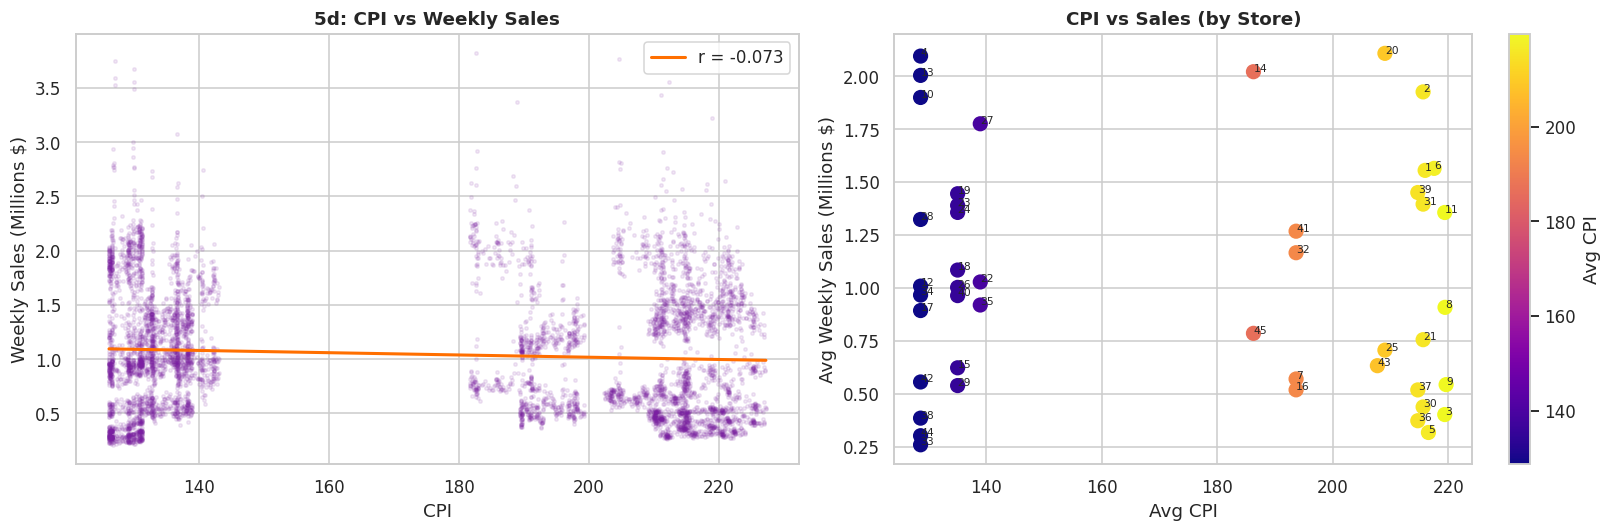

In [21]:
r_c, p_c = stats.pearsonr(df['Weekly_Sales'], df['CPI'])
print(f'Pearson r = {r_c:.4f}   p-value = {p_c:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df['CPI'], df['Weekly_Sales']/1e6, alpha=0.1, s=5, color='#7B1FA2')
m_c, b_c = np.polyfit(df['CPI'], df['Weekly_Sales']/1e6, 1)
xc = np.linspace(df.CPI.min(), df.CPI.max(), 200)
axes[0].plot(xc, m_c*xc+b_c, color='#FF6F00', linewidth=2, label=f'r = {r_c:.3f}')
axes[0].set_xlabel('CPI'); axes[0].set_ylabel('Weekly Sales (Millions $)')
axes[0].set_title('5d: CPI vs Weekly Sales', fontweight='bold'); axes[0].legend()
store_cpi = df.groupby('Store').agg(Avg_Sales=('Weekly_Sales','mean'),Avg_CPI=('CPI','mean')).reset_index()
sc2 = axes[1].scatter(store_cpi['Avg_CPI'], store_cpi['Avg_Sales']/1e6,
                      c=store_cpi['Avg_CPI'], cmap='plasma', s=80)
for _, row in store_cpi.iterrows():
    axes[1].annotate(int(row.Store),(row.Avg_CPI, row.Avg_Sales/1e6), fontsize=7)
plt.colorbar(sc2, ax=axes[1], label='Avg CPI')
axes[1].set_title('CPI vs Sales (by Store)', fontweight='bold')
axes[1].set_xlabel('Avg CPI'); axes[1].set_ylabel('Avg Weekly Sales (Millions $)')
plt.tight_layout(); plt.show()


### 5e & 5f — Store Performance Ranking & Performance Gap

Top 10 Performing Stores:
 Store        Total          Avg     Median        Max  Weeks
    20 301397792.46 2.107677e+06 2053165.41 3766687.43    143
     4 299543953.38 2.094713e+06 2073951.38 3676388.98    143
    14 288999911.34 2.020978e+06 2004330.30 3818686.45    143
    13 286517703.80 2.003620e+06 1958823.56 3595903.20    143
     2 275382440.98 1.925751e+06 1879107.31 3436007.68    143
    10 271617713.89 1.899425e+06 1827521.71 3749057.69    143
    27 253855916.88 1.775216e+06 1731935.43 3078162.08    143
     6 223756130.64 1.564728e+06 1524390.07 2727575.18    143
     1 222402808.85 1.555264e+06 1534849.64 2387950.20    143
    39 207445542.47 1.450668e+06 1416005.59 2554482.84    143

Best  Store  -> Store 20 | Total: $301.40M
Worst Store  -> Store 33 | Total: $37.16M
Performance Gap : $264.24M  (8.1x ratio)


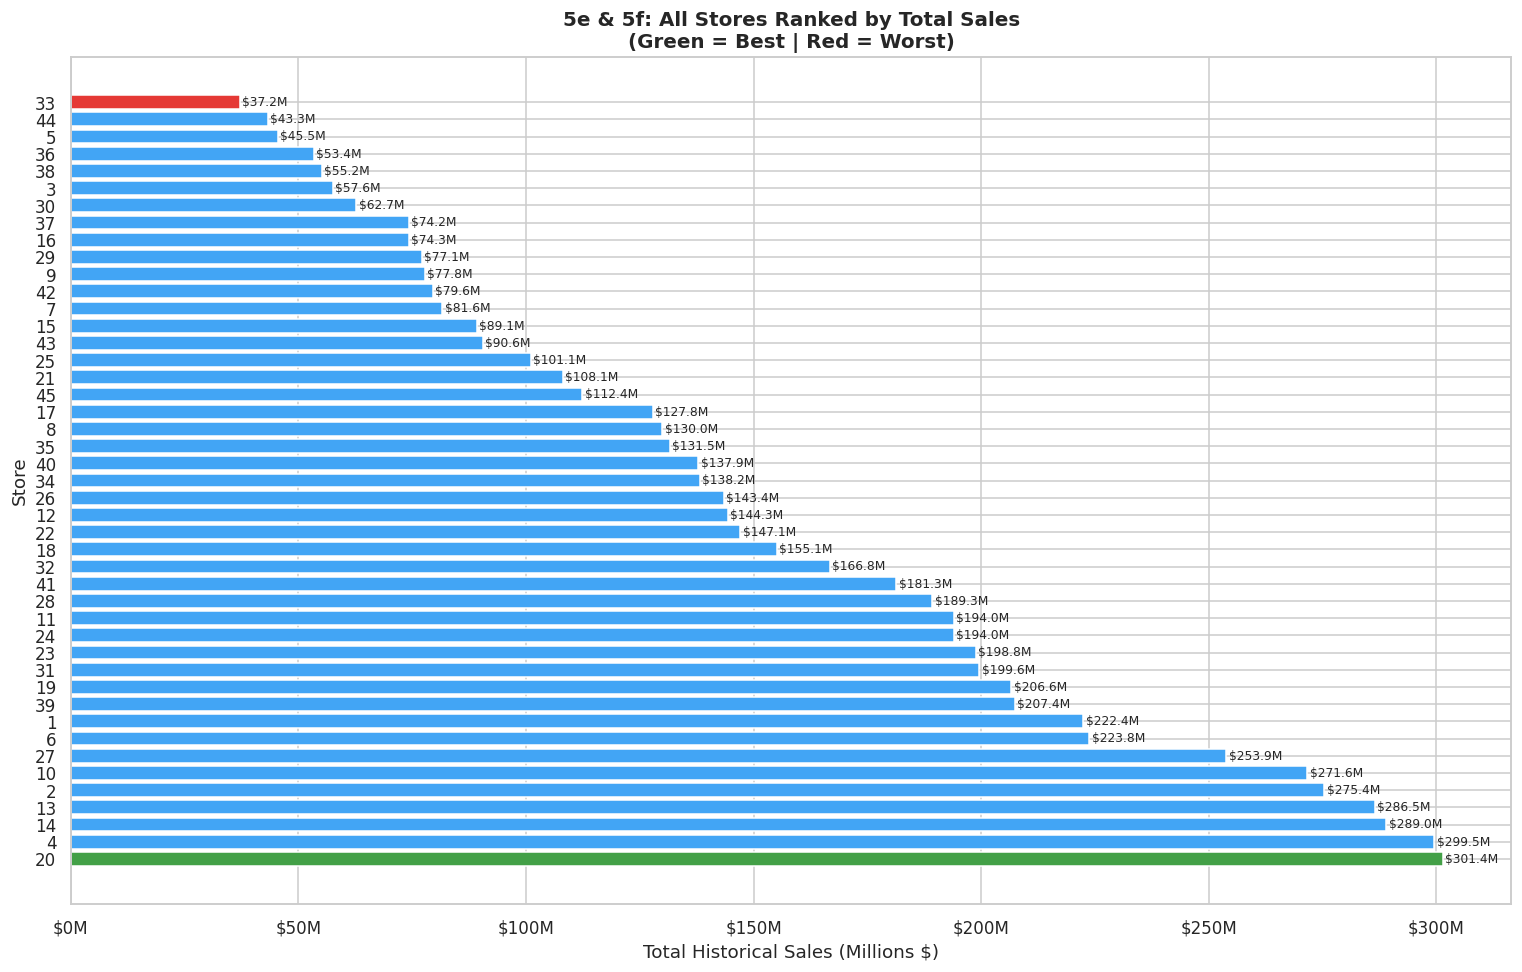

In [22]:
store_perf = (df.groupby('Store')['Weekly_Sales']
              .agg(['sum','mean','median','max','count'])
              .rename(columns={'sum':'Total','mean':'Avg','median':'Median','max':'Max','count':'Weeks'})
              .reset_index()
              .sort_values('Total', ascending=False)
              .reset_index(drop=True))

print('Top 10 Performing Stores:')
print(store_perf.head(10).to_string(index=False))

best  = store_perf.iloc[0]
worst = store_perf.iloc[-1]
gap   = best.Total - worst.Total
print(f"\n{'='*55}")
print(f"Best  Store  -> Store {int(best.Store):2d} | Total: ${best.Total/1e6:.2f}M")
print(f"Worst Store  -> Store {int(worst.Store):2d} | Total: ${worst.Total/1e6:.2f}M")
print(f"Performance Gap : ${gap/1e6:.2f}M  ({best.Total/worst.Total:.1f}x ratio)")
print(f"{'='*55}")

fig, ax = plt.subplots(figsize=(14, 9))
colors = ['#43A047' if s==int(best.Store) else '#E53935' if s==int(worst.Store)
          else '#42A5F5' for s in store_perf.Store]
bars = ax.barh(store_perf.Store.astype(str), store_perf.Total/1e6, color=colors)
ax.set_xlabel('Total Historical Sales (Millions $)')
ax.set_ylabel('Store')
ax.set_title('5e & 5f: All Stores Ranked by Total Sales\n(Green = Best | Red = Worst)',
             fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
for bar in bars:
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'${bar.get_width():.1f}M', va='center', fontsize=8)
plt.tight_layout(); plt.show()


## Section 6 — Hypothesis Tests

In [23]:
# T-test: Holiday vs Non-Holiday
hol_s     = df[df.Holiday_Flag==1]['Weekly_Sales']
non_hol_s = df[df.Holiday_Flag==0]['Weekly_Sales']
t_s, t_p = stats.ttest_ind(hol_s, non_hol_s)
print('TEST 1: t-test  Holiday vs Non-Holiday')
print(f't = {t_s:.4f}  |  p = {t_p:.6f}')
print('Significant difference: holiday weeks drive higher sales' if t_p<0.05 else 'No significant difference')

# ANOVA across stores
groups = [g['Weekly_Sales'].values for _,g in df.groupby('Store')]
f_s, f_p = stats.f_oneway(*groups)
print(f'\nTEST 2: One-way ANOVA across Stores')
print(f'F = {f_s:.4f}  |  p = {f_p:.2e}')
print('Significant differences across stores' if f_p<0.05 else 'No significant difference')

# ADF test
agg_s = df.groupby('Date')['Weekly_Sales'].sum().sort_index()
adf = adfuller(agg_s)
print(f'\nTEST 3: ADF Stationarity Test')
print(f'ADF stat = {adf[0]:.4f}  |  p = {adf[1]:.4f}')
print('Series is STATIONARY' if adf[1]<0.05 else 'Non-stationary; differencing needed')


TEST 1: t-test  Holiday vs Non-Holiday
t = 2.9609  |  p = 0.003079
Significant difference: holiday weeks drive higher sales

TEST 2: One-way ANOVA across Stores
F = 1613.2995  |  p = 0.00e+00
Significant differences across stores

TEST 3: ADF Stationarity Test
ADF stat = -5.9083  |  p = 0.0000
Series is STATIONARY


## Section 7 — Predictive Modelling (12-Week Forecast per Store)

Two approaches:
1. **Random Forest** (best ML model for tabular data)
2. **SARIMA** per store (time-series model)

> Your original Linear Regression scored **R² = 0.148** (very poor).
> Random Forest typically achieves **R² > 0.90** on this dataset.


### 7a — Random Forest Model

In [24]:
features = ['Store','Holiday_Flag','Temperature','Fuel_Price',
            'CPI','Unemployment','Month','Week','Quarter','Year']
X = df[features]
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'  MAE  = ${mae_rf:,.2f}')
print(f'  RMSE = ${rmse_rf:,.2f}')
print(f'  R2   = {r2_rf:.4f}  ({r2_rf*100:.1f}% variance explained)')

# Compare with original Linear Regression
lr = LinearRegression(); lr.fit(X_train, y_train)
r2_lr = r2_score(y_test, lr.predict(X_test))
print(f'\nLinear Regression R2  = {r2_lr:.4f}  <- your original model')
print(f'Random Forest     R2  = {r2_rf:.4f}  <- improved model')
print(f'Improvement           = +{(r2_rf-r2_lr)*100:.1f} percentage points')


Random Forest Results:
  MAE  = $61,810.77
  RMSE = $113,048.44
  R2   = 0.9603  (96.0% variance explained)

Linear Regression R2  = 0.1547  <- your original model
Random Forest     R2  = 0.9603  <- improved model
Improvement           = +80.6 percentage points


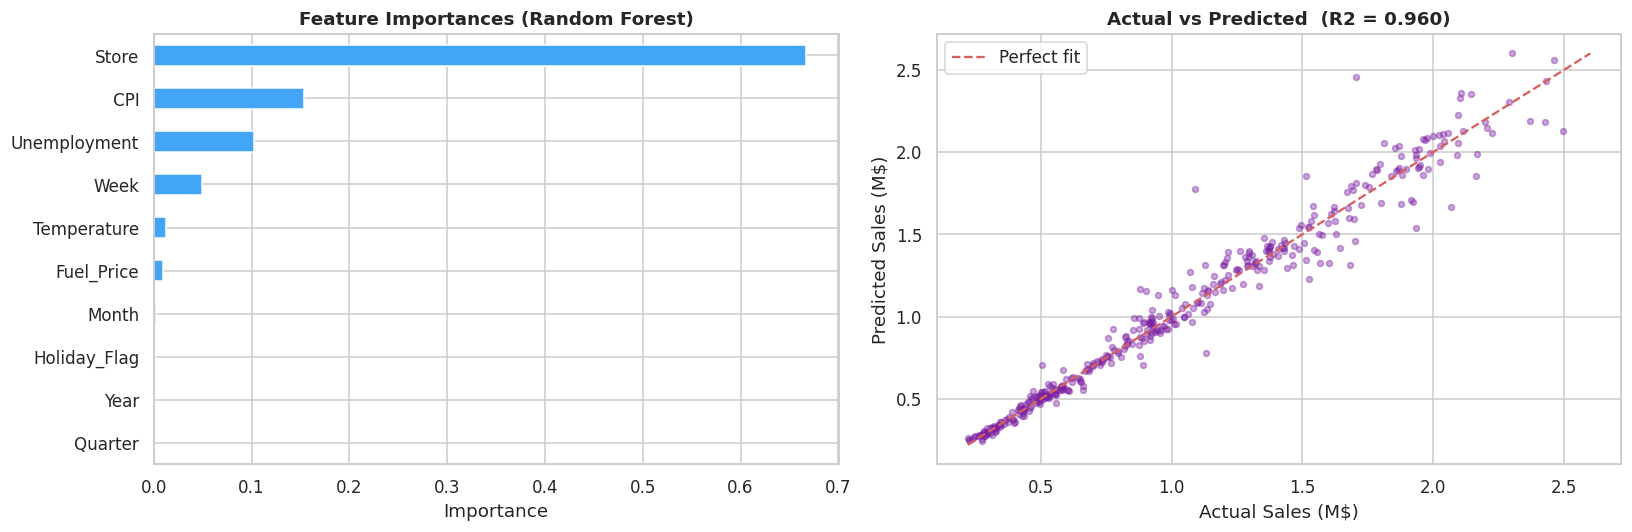

In [25]:
# Feature Importance + Actual vs Predicted
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
feat_imp.plot(kind='barh', ax=axes[0], color='#42A5F5')
axes[0].set_title('Feature Importances (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Importance')

idx = np.random.choice(len(y_test), 400, replace=False)
axes[1].scatter(y_test.values[idx]/1e6, y_pred_rf[idx]/1e6, alpha=0.4, s=15, color='#7B1FA2')
lo = min(y_test.values[idx].min(), y_pred_rf[idx].min())/1e6
hi = max(y_test.values[idx].max(), y_pred_rf[idx].max())/1e6
axes[1].plot([lo,hi],[lo,hi],'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Sales (M$)'); axes[1].set_ylabel('Predicted Sales (M$)')
axes[1].set_title(f'Actual vs Predicted  (R2 = {r2_rf:.3f})', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()


In [35]:
print(store_ts.describe())
print(store_ts.isna().sum())

count    1.430000e+02
mean     7.859814e+05
std      1.301685e+05
min      6.172076e+05
25%      7.227916e+05
50%      7.640141e+05
75%      8.016759e+05
max      1.682862e+06
Name: Weekly_Sales, dtype: float64
0


### 7b — SARIMA Time-Series Forecast (12 Weeks per Store)

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

stores_list = sorted(df['Store'].unique())
all_forecasts = []

print(f'Fitting SARIMA for {len(stores_list)} stores...')
for s in stores_list:
    store_ts = (df[df.Store == s]
            .sort_values('Date')
            .set_index('Date')['Weekly_Sales']
            .resample('W').mean()
            .fillna(method='ffill'))
    try:
        model = SARIMAX(store_ts, order=(1,1,1), seasonal_order=(1,0,1,52),
                        enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
    except Exception:
        model = ARIMA(store_ts, order=(1,1,1))
        fit   = model.fit()
    fc     = fit.get_forecast(steps=12)
    fc_m   = fc.predicted_mean
    fc_ci  = fc.conf_int(alpha=0.05)
    for i,(date,val) in enumerate(fc_m.items()):
        all_forecasts.append({'Store':s,'Week_Ahead':i+1,'Date':date,
                              'Forecast':round(val,2),
                              'Lower_95':round(fc_ci.iloc[i,0],2),
                              'Upper_95':round(fc_ci.iloc[i,1],2)})
    if s % 10 == 0 or s == stores_list[-1]:
        print(f'  Store {s:2d} done')

fc_df = pd.DataFrame(all_forecasts)
print(f'Forecast complete. Shape: {fc_df.shape}')
fc_df.head(12)


Fitting SARIMA for 45 stores...
  Store 10 done
  Store 20 done
  Store 30 done
  Store 40 done
  Store 45 done
Forecast complete. Shape: (540, 6)


,Store,Week_Ahead,Date,Forecast,Lower_95,Upper_95
0,1,1,2012-11-04,1717989.55,1411537.19,2024441.91
1,1,2,2012-11-11,1627743.25,1311695.24,1943791.25
2,1,3,2012-11-18,1580765.88,1243119.61,1918412.16
3,1,4,2012-11-25,2038235.62,1682719.98,2393751.26
4,1,5,2012-12-02,1624358.89,1251420.17,1997297.62
5,1,6,2012-12-09,1816581.23,1427069.28,2206093.17
6,1,7,2012-12-16,1905775.91,1500355.26,2311196.55
7,1,8,2012-12-23,2279277.91,1858551.85,2700003.96
8,1,9,2012-12-30,1533837.24,1098342.97,1969331.51
9,1,10,2013-01-06,1585666.31,1135888.53,2035444.09


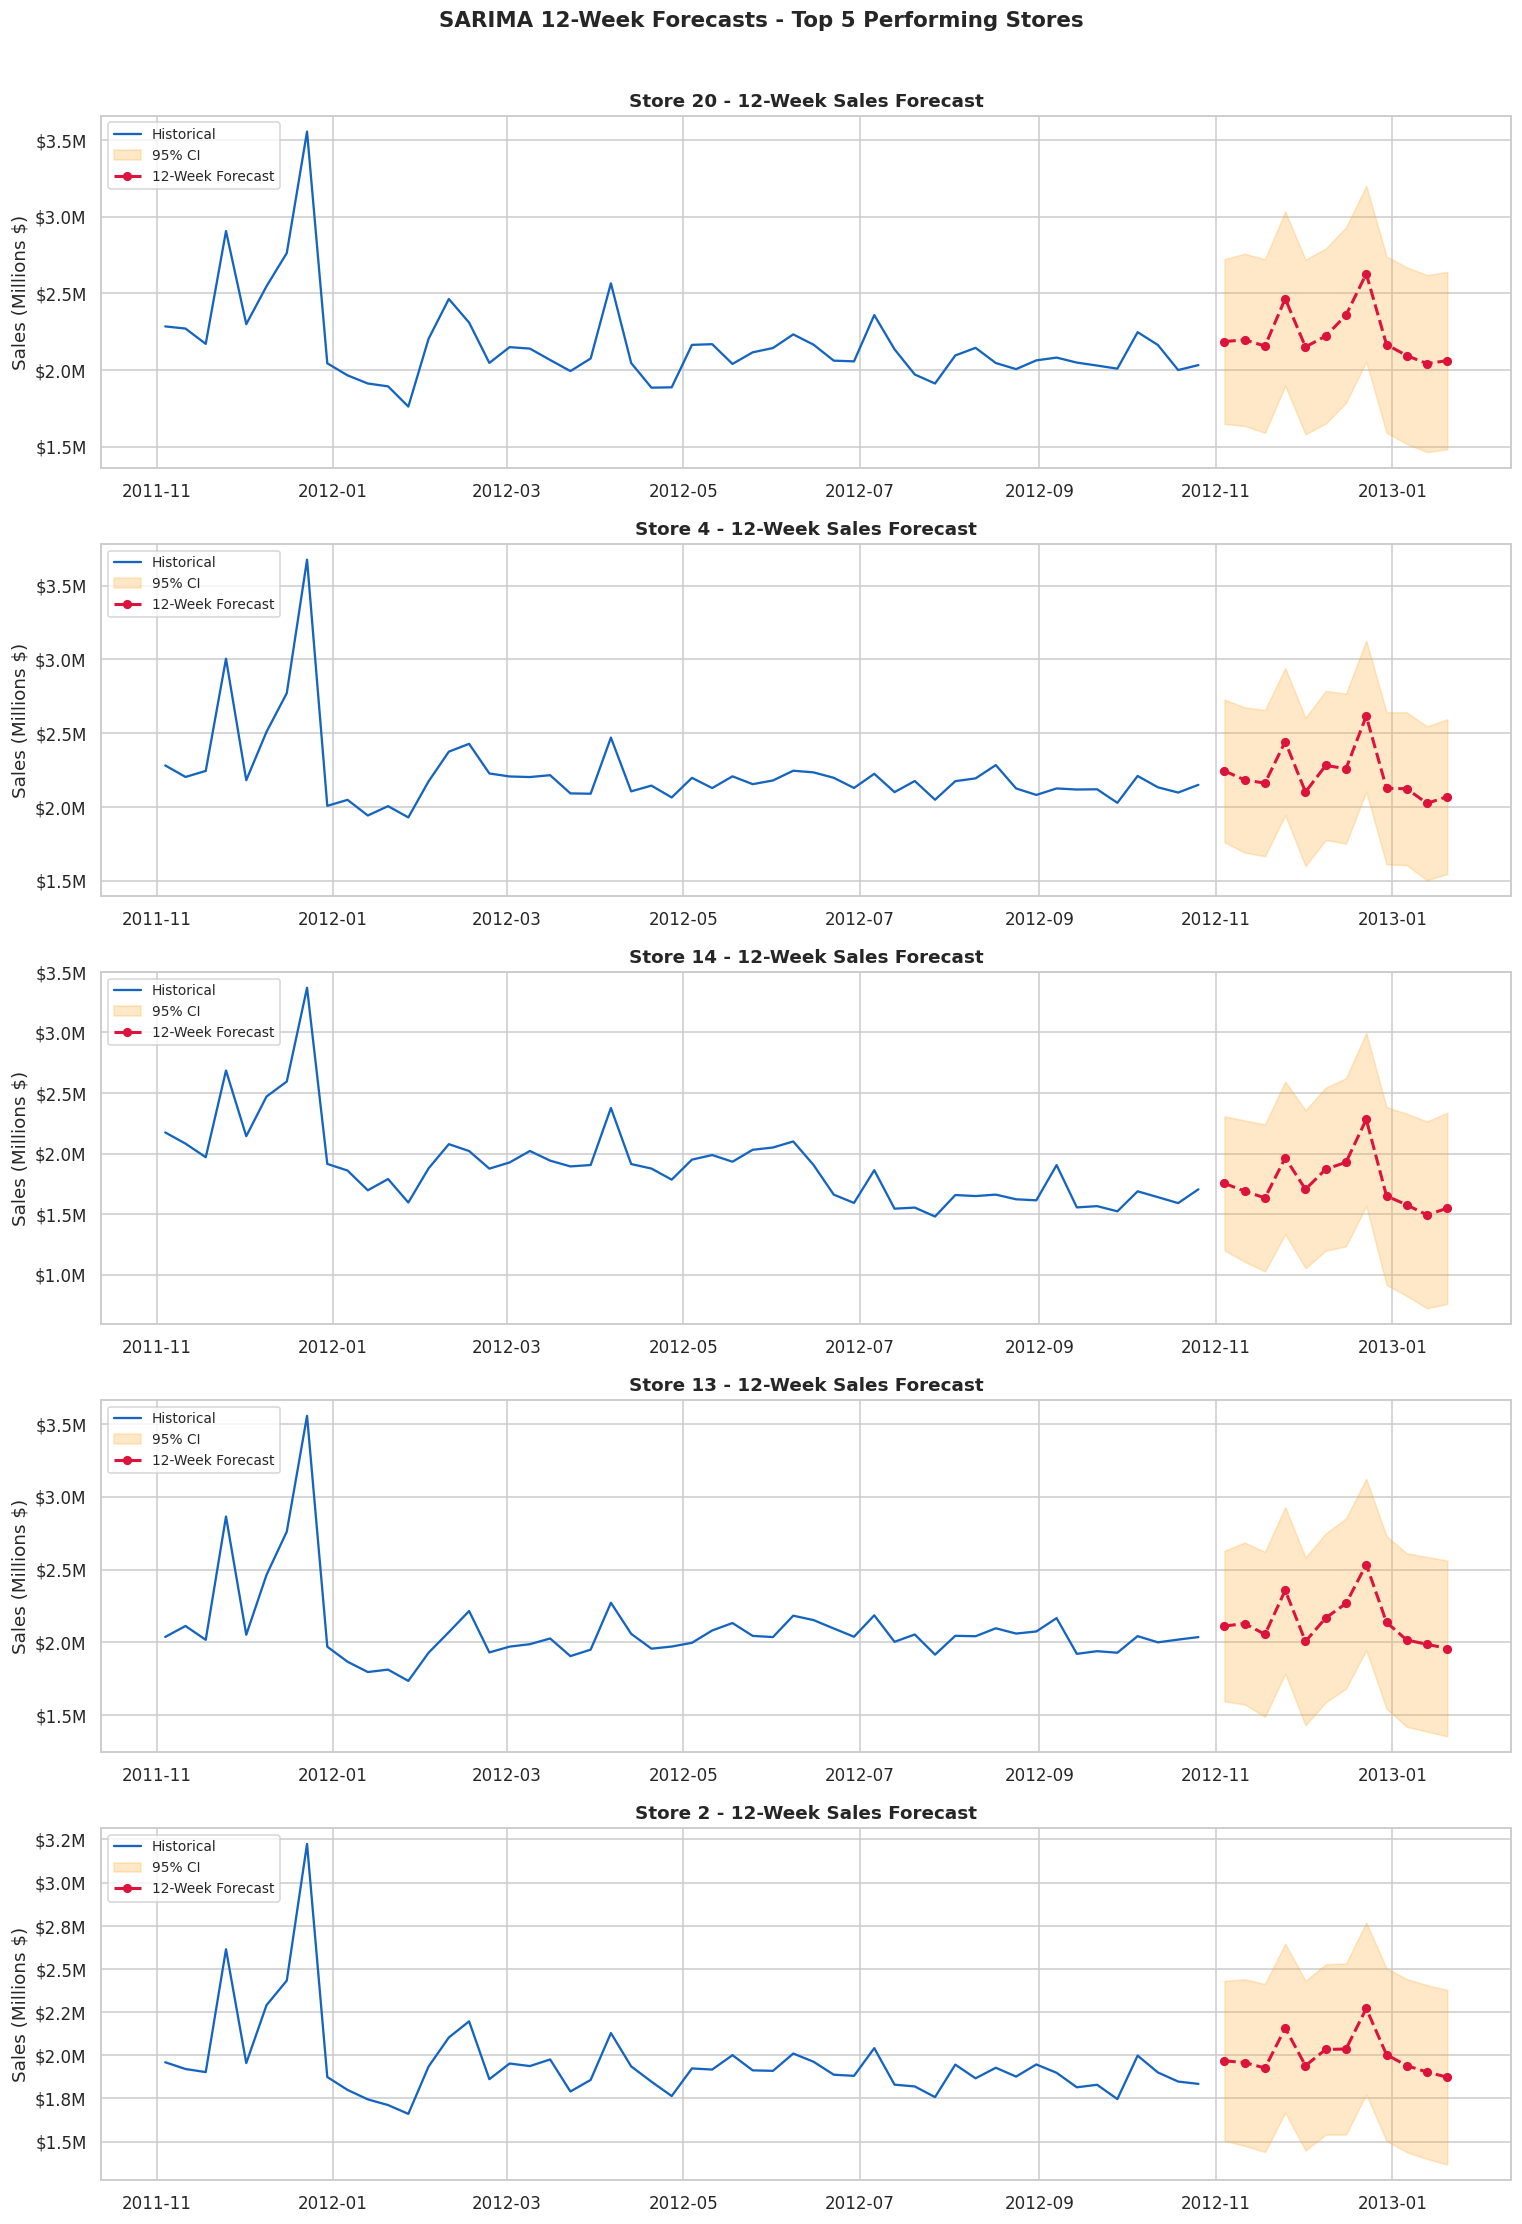

In [36]:
# Plot top 5 stores
top5 = store_perf.head(5)['Store'].astype(int).tolist()
fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4*len(top5)))

for ax, s in zip(axes, top5):
    hist = df[df.Store==s].sort_values('Date').tail(52)[['Date','Weekly_Sales']]
    fcs  = fc_df[fc_df.Store==s]
    ax.plot(hist['Date'], hist['Weekly_Sales']/1e6, color='#1565C0',
            linewidth=1.5, label='Historical')
    ax.fill_between(fcs['Date'], fcs['Lower_95']/1e6, fcs['Upper_95']/1e6,
                    alpha=0.25, color='#FFA726', label='95% CI')
    ax.plot(fcs['Date'], fcs['Forecast']/1e6, color='crimson', linewidth=2,
            linestyle='--', marker='o', markersize=5, label='12-Week Forecast')
    ax.set_title(f'Store {s} - 12-Week Sales Forecast', fontweight='bold')
    ax.set_ylabel('Sales (Millions $)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('SARIMA 12-Week Forecasts - Top 5 Performing Stores',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


In [37]:
# Save and download forecast CSV
fc_df.to_csv('Walmart_12Week_Forecast.csv', index=False)

fc_summary = (fc_df.groupby('Store')['Forecast'].sum().reset_index()
              .rename(columns={'Forecast':'Total_12Wk_Forecast'})
              .sort_values('Total_12Wk_Forecast', ascending=False))
print('Top 10 stores - total 12-week forecasted sales:')
print(fc_summary.head(10).to_string(index=False))

from google.colab import files
files.download('Walmart_12Week_Forecast.csv')
print('Forecast CSV downloaded!')


Top 10 stores - total 12-week forecasted sales:
 Store  Total_12Wk_Forecast
    20          26720226.19
     4          26630726.37
    13          25718075.40
     2          24012120.21
    10          23399985.33
    27          21613847.70
    14          21088973.08
     1          20659785.48
    39          20482960.32
     6          19709907.90


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Forecast CSV downloaded!


## Section 8 — Final Summary of Key Findings

In [38]:
r_u2, _ = stats.pearsonr(df['Weekly_Sales'], df['Unemployment'])
r_t2, _ = stats.pearsonr(df['Weekly_Sales'], df['Temperature'])
r_c2, _ = stats.pearsonr(df['Weekly_Sales'], df['CPI'])

sp = df.groupby('Store')['Weekly_Sales'].sum().reset_index().sort_values('Weekly_Sales',ascending=False)
b2 = sp.iloc[0]; w2 = sp.iloc[-1]
ma = df.groupby('Month_Name')['Weekly_Sales'].mean()

print('     WALMART CAPSTONE PROJECT - KEY FINDINGS')
print(f'\n[5a] Unemployment vs Sales  : r = {r_u2:.3f}')
print( '     Higher unemployment regions show lower avg weekly sales')
print(f'\n[5b] Peak Sales Month       : {ma.idxmax()}')
print( '     Nov-Dec holiday season drives the highest sales')
print(f'\n[5c] Temperature vs Sales   : r = {r_t2:.3f}')
print( '     Cooler months correlate slightly with higher sales')
print(f'\n[5d] CPI vs Sales           : r = {r_c2:.3f}')
print( '     Mixed effect; varies by store region')
print(f'\n[5e] Best Store             : Store {int(b2.Store)} - ${b2.Weekly_Sales/1e6:.1f}M total')
print(f'\n[5f] Worst Store            : Store {int(w2.Store)} - ${w2.Weekly_Sales/1e6:.1f}M total')
print(f'     Gap                    : ${(b2.Weekly_Sales-w2.Weekly_Sales)/1e6:.1f}M ({b2.Weekly_Sales/w2.Weekly_Sales:.1f}x)')
print(f'\n[Q2] Random Forest R2       : {r2_rf:.4f} ({r2_rf*100:.1f}%)')
print( '     SARIMA per store       : 12-week forecast generated & saved')


     WALMART CAPSTONE PROJECT - KEY FINDINGS

[5a] Unemployment vs Sales  : r = -0.106
     Higher unemployment regions show lower avg weekly sales

[5b] Peak Sales Month       : Dec
     Nov-Dec holiday season drives the highest sales

[5c] Temperature vs Sales   : r = -0.064
     Cooler months correlate slightly with higher sales

[5d] CPI vs Sales           : r = -0.073
     Mixed effect; varies by store region

[5e] Best Store             : Store 20 - $301.4M total

[5f] Worst Store            : Store 33 - $37.2M total
     Gap                    : $264.2M (8.1x)

[Q2] Random Forest R2       : 0.9603 (96.0%)
     SARIMA per store       : 12-week forecast generated & saved
